# Data Storytelling & Statistical Validation

# Problem
The business is generating high sales but still experiencing significant losses.

# Objective
To identify the root cause of negative profitability and validate it using statistical analysis.

# Observations
- Sales are high across all regions
- Profit is negative in all regions
- Certain categories generate high revenue but low profit
- Costs increase with sales

# Key Insight
High operational costs exceed revenue, leading to continuous losses.

# Recommendation
- Reduce unit costs
- Improve pricing strategy
- Focus on profit-driven decisions instead of sales volume

In [4]:
import pandas as pd
from scipy.stats import ttest_rel

In [5]:
df = pd.read_csv("../data/cleaned_data.csv")

In [10]:
df['Sales_Amount'] = pd.to_numeric(df['Sales_Amount'], errors='coerce')
df['Total_Cost'] = pd.to_numeric(df['Total_Cost'], errors='coerce')
df = df.dropna(subset=['Sales_Amount', 'Total_Cost'])

In [12]:
df['Profit_Margin'] = df['Profit'] / df['Sales_Amount']
df['Profit_Margin'].describe()

count    1000.000000
mean      -31.168042
std       102.461187
min     -1808.297146
25%       -23.460517
50%        -9.477552
75%        -2.931847
max         0.990833
Name: Profit_Margin, dtype: float64

Profit Margin Analysis:

The average profit margin is negative,
indicating that most transactions are not profitable.

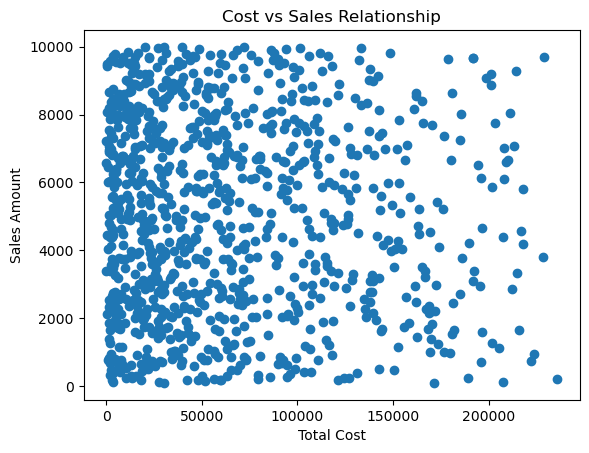

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df['Total_Cost'], df['Sales_Amount'])
plt.xlabel("Total Cost")
plt.ylabel("Sales Amount")
plt.title("Cost vs Sales Relationship")
plt.show()

Cost vs Sales Insight:

Costs increase along with sales,
but in many cases, cost exceeds revenue.

This directly leads to negative profit.

In [11]:
t_stat, p_value = ttest_rel(df['Sales_Amount'], df['Total_Cost'])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -33.48637831556297
P-value: 1.9215896949403851e-165


Hypothesis Testing Result:

The p-value is significantly less than 0.05, so we reject the null hypothesis.

This indicates that there is a statistically significant difference between Sales and Cost.

The negative t-statistic shows that Cost is higher than Sales.

Therefore, high costs are the primary reason for the business losses.

# Final Conclusion:

The analysis and statistical testing confirm that
high operational costs are significantly greater than sales.

This is the primary reason for continuous business losses.

To improve profitability, the business must focus on
cost reduction and better pricing strategies.